<a href="https://colab.research.google.com/github/laiimour/cqv-hac-mopso/blob/main/02_CQV_Adaptativo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane
!pip install pennylane-qiskit
!pip install pennylane-lightning


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 109.5 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 

In [11]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import random
import math
import scipy.stats

np.random.seed(42)
random.seed(42)

# Código 2

# PREPARAÇÃO E PARTICIONAMENTO DOS DADOS (3.1 e 6.1)

iris = load_iris()
X = iris.data[:100]  #Classes 0 e 1 (binário)
Y = iris.target[:100]
Y = Y * 2 - 1

# O artigo introduz PCA para redução de dimensionalidade e extração de características.
# Duplicamos as componentes principais para mapear nas 2 partições lógicas (4 qubits cada).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

# Normalização para codificação de ângulo (AngleEmbedding)
norm = np.sqrt(np.sum(X_pca**2, axis=-1, keepdims=True))
X_norm = X_pca / norm

# Duas partições simuladas (ex: características locais vs globais extraídas)
X_pad = np.hstack((X_norm, X_norm))

indices = np.random.permutation(len(Y))
X_pad, Y = X_pad[indices], Y[indices]

X_treino, Y_treino = X_pad[:75], Y[:75]
X_teste, Y_teste = X_pad[75:], Y[75:]

def particionar_dados(x):
    return x[:4], x[4:]

# DEFINIÇÃO DA CAMADA PARALELA E INTERATIVA (4.2 e 5.2)

def ansatz_circular(pesos, qubits):
    """Hardware-efficient ansatz (HEA) com topologia circular."""
    for i, q in enumerate(qubits):
        qml.RY(pesos[i], wires=q)
    for i in range(len(qubits)):
        qml.CRZ(pesos[len(qubits) + i], wires=[qubits[i], qubits[(i+1)%len(qubits)]])

GATES_SET = ['CRX', 'CRY', 'CRZ', 'CX', 'CY', 'CZ', 'RX', 'RY', 'RZ']

def aplicar_porta(porta, controle, alvo, peso):
    """Mapeamento da porta selecionada pelo MOPSO."""
    if porta == 'CRX': qml.CRX(peso, wires=[controle, alvo])
    elif porta == 'CRY': qml.CRY(peso, wires=[controle, alvo])
    elif porta == 'CRZ': qml.CRZ(peso, wires=[controle, alvo])
    elif porta == 'CX': qml.CNOT(wires=[controle, alvo])
    elif porta == 'CY': qml.CY(wires=[controle, alvo])
    elif porta == 'CZ': qml.CZ(wires=[controle, alvo])
    elif porta == 'RX': qml.RX(peso, wires=alvo) # Portas SU aplicadas ao alvo
    elif porta == 'RY': qml.RY(peso, wires=alvo)
    elif porta == 'RZ': qml.RZ(peso, wires=alvo)

def ansatz_interativo(pesos, qubits, config_portas):
    """Camada interativa configurável pelo MOPSO com topologia circular."""
    idx = 0
    # Camada inicial de rotação
    for q in qubits:
        qml.RY(pesos[idx], wires=q); idx += 1

    m = len(qubits)
    for i in range(m):
        controle = qubits[i]
        alvo = qubits[(i+1)%m]
        porta = config_portas[i]

        # Consome peso apenas se for porta parametrizada
        if porta in ['CRX', 'CRY', 'CRZ', 'RX', 'RY', 'RZ']:
            aplicar_porta(porta, controle, alvo, pesos[idx])
            idx += 1
        else:
            aplicar_porta(porta, controle, alvo, 0)

# 3. TREINAMENTO DA CAMADA PARALELA (4.3.1)

dev_paralelo = qml.device("default.qubit", wires=4)

@qml.qnode(dev_paralelo)
def circ_paralelo(pesos, x_part):
    qml.AngleEmbedding(features=x_part, wires=range(4), rotation='Y')
    ansatz_circular(pesos, range(4))
    return qml.expval(qml.PauliZ(0))

def treinar_camada_paralela(X_part, Y_treino):
    print("A treinar partição paralela de forma independente...")
    pesos = np.random.randn(8, requires_grad=True) * 0.1
    opt = qml.AdamOptimizer(stepsize=0.1)

    def custo(p, x_batch, y_batch):
        prev = np.array([circ_paralelo(p, x) for x in x_batch])
        return np.mean((y_batch - prev)**2)

    # Treino rápido simulado (5 iterações) para obter pesos fixos
    for it in range(5):
        pesos = opt.step(custo, pesos, x_batch=X_part[:20], y_batch=Y_treino[:20])
    return pesos

# Obtenção do "Fixed Parameter Set: theta'"
pesos_fixos_esq = treinar_camada_paralela([particionar_dados(x)[0] for x in X_treino], Y_treino)
pesos_fixos_dir = treinar_camada_paralela([particionar_dados(x)[1] for x in X_treino], Y_treino)


# 4. HAC-SA: SELEÇÃO ADAPTATIVA DE QUBITS (4.3.2)

def executar_hac_sa(X, Y, pesos_e, pesos_d, V=2, max_iter=10):
    print("\n[HAC-SA] A procurar fusão de qubits (Simulated Annealing)...")
    import itertools
    comb_esq = list(itertools.combinations([0,1,2,3], V))
    comb_dir = list(itertools.combinations([4,5,6,7], V))

    dev_local = qml.device("default.qubit", wires=8)

    def custo_selecao(comb_e, comb_d):
        qubits_selecionados = list(comb_e) + list(comb_d)

        @qml.qnode(dev_local)
        def circ_sa(pesos_int, x):
            x1, x2 = particionar_dados(x)
            qml.AngleEmbedding(features=x1, wires=[0,1,2,3], rotation='Y')
            qml.AngleEmbedding(features=x2, wires=[4,5,6,7], rotation='Y')
            # Camadas fixas
            ansatz_circular(pesos_e, [0,1,2,3])
            ansatz_circular(pesos_d, [4,5,6,7])
            # Avaliação interativa
            ansatz_circular(pesos_int, qubits_selecionados)
            return qml.expval(qml.PauliZ(qubits_selecionados[0]))

        p_teste = np.random.randn(8) * 0.1
        prev = np.array([circ_sa(p_teste, x) for x in X[:10]])
        return np.mean((Y[:10] - prev)**2)

    # SA Setup
    melhor_custo = float('inf')
    melhor_comb = (comb_esq[0], comb_dir[0])
    temp = 100.0

    for _ in range(max_iter):
        nova_comb = (random.choice(comb_esq), random.choice(comb_dir))
        custo = custo_selecao(nova_comb[0], nova_comb[1])

        if custo < melhor_custo or random.random() < math.exp(-(custo - melhor_custo) / temp):
            melhor_custo = custo
            melhor_comb = nova_comb
        temp *= 0.8

    print(f"Melhor união selecionada: Esq {melhor_comb[0]}, Dir {melhor_comb[1]}")
    return list(melhor_comb[0]) + list(melhor_comb[1])

qubits_raiz = executar_hac_sa(X_treino, Y_treino, pesos_fixos_esq, pesos_fixos_dir)


# 5. MOPSO: OTIMIZAÇÃO RIGOROSA DE PORTAS (5)

dev_mopso = qml.device("default.qubit", wires=len(qubits_raiz))

@qml.qnode(dev_mopso)
def circ_mopso_state(pesos, config_portas):
    """Devolve o estado quântico para expressividade."""
    ansatz_interativo(pesos, range(len(qubits_raiz)), config_portas)
    return qml.state()

@qml.qnode(dev_mopso)
def circ_mopso_dm(pesos, config_portas, alvo):
    """Devolve a matriz de densidade reduzida para um qubit específico."""
    ansatz_interativo(pesos, range(len(qubits_raiz)), config_portas)
    return qml.density_matrix([alvo])

def calcular_meyer_wallach(config_portas, num_params, n_qubits, num_samples=10):
    """Cálculo rigoroso da medida de emaranhamento de Meyer-Wallach."""
    mw_sum = 0.0
    for _ in range(num_samples):
        pesos = np.random.uniform(0, 2*np.pi, num_params)
        pureza_soma = 0.0
        for k in range(n_qubits):
            rho_k = circ_mopso_dm(pesos, config_portas, k)
            pureza = np.trace(np.dot(rho_k, rho_k)).real
            pureza_soma += pureza
        # MW para o estado atual amostrado
        mw_sum += 2.0 * (1.0 - (1.0 / n_qubits) * pureza_soma)

    return mw_sum / num_samples

def metricas_mopso(config_portas, num_samples=50):
    """Cálculo estrito das métricas f1 (Expr), f2 (MW Entanglement) e f3 (Depth)."""
    # f3: Profundidade do circuito (estimativa de custo de portas)
    f3 = sum([2 if p in ['CRX', 'CRY', 'CRZ', 'CX', 'CY', 'CZ'] else 1 for p in config_portas])

    num_params = len(qubits_raiz) + sum([1 for p in config_portas if p in ['CRX', 'CRY', 'CRZ', 'RX', 'RY', 'RZ']])
    n_qubits = len(qubits_raiz)
    N = 2 ** n_qubits

    # 1. Emaranhamento (Meyer-Wallach) - Minimizar 1 - Ent [Eq. 5.2 do artigo]
    entanglement = calcular_meyer_wallach(config_portas, num_params, n_qubits, num_samples=10)
    f2_ent = 1.0 - entanglement

    # 2. Expressividade (Divergência KL) - Minimizar Expr [Eq. 5.1 do artigo]
    fidelities = []
    for _ in range(num_samples):
        p1 = np.random.uniform(0, 2*np.pi, num_params)
        p2 = np.random.uniform(0, 2*np.pi, num_params)
        state1 = circ_mopso_state(p1, config_portas)
        state2 = circ_mopso_state(p2, config_portas)
        fid = np.abs(np.vdot(state1, state2))**2
        fidelities.append(fid)

    hist_pqc, _ = np.histogram(fidelities, bins=10, range=(0, 1), density=True)
    bin_centers = np.linspace(0.05, 0.95, 10)
    hist_haar = (N - 1) * (1 - bin_centers)**(N - 2)
    hist_haar = hist_haar / np.sum(hist_haar)
    hist_pqc = np.where(hist_pqc == 0, 1e-10, hist_pqc) / np.sum(hist_pqc)

    f1_expr = scipy.stats.entropy(hist_pqc, hist_haar)

    return [f1_expr, f2_ent, f3]

# --- ESTRUTURA DO MOPSO ---
class Particula:
    def __init__(self, dim):
        # Posição contínua que será mapeada para índices de GATES_SET
        self.posicao = np.random.uniform(0, len(GATES_SET) - 1, dim)
        self.velocidade = np.random.uniform(-1, 1, dim)
        self.pbest_pos = self.posicao.copy()
        self.pbest_fit = [float('inf'), float('inf'), float('inf')]
        self.fit = [float('inf'), float('inf'), float('inf')]

    def obter_config_portas(self):
        # Converte a posição para um array numpy padrão antes de arredondar e indexar
        pos_np = np.atleast_1d(self.posicao)
        indices = np.clip(np.round(pos_np).astype(int), 0, len(GATES_SET) - 1)
        return [GATES_SET[i] for i in indices]

def domina(fit1, fit2):
    """Verifica se fit1 domina fit2 na fronteira de Pareto."""
    return all(f1 <= f2 for f1, f2 in zip(fit1, fit2)) and any(f1 < f2 for f1, f2 in zip(fit1, fit2))

def executar_mopso(max_iter=5, num_particulas=10):
    print("\n[MOPSO] A iniciar otimização multi-objetivo (Fronteira de Pareto)...")
    dim = len(qubits_raiz)
    enxame = [Particula(dim) for _ in range(num_particulas)]
    arquivo_pareto = [] # Armazena as soluções não-dominadas

    for it in range(max_iter):
        print(f"  -> Iteração MOPSO {it+1}/{max_iter}")
        for p in enxame:
            config = p.obter_config_portas()
            p.fit = metricas_mopso(config)

            # Atualizar Personal Best (pbest)
            if domina(p.fit, p.pbest_fit):
                p.pbest_fit = p.fit.copy()
                p.pbest_pos = p.posicao.copy()

            # Atualizar Arquivo de Pareto (gbest)
            dominado = False
            for arq_p in arquivo_pareto:
                if domina(arq_p['fit'], p.fit):
                    dominado = True
                    break
            if not dominado:
                # Remove do arquivo quem for dominado por p
                arquivo_pareto = [arq for arq in arquivo_pareto if not domina(p.fit, arq['fit'])]
                arquivo_pareto.append({'pos': p.posicao.copy(), 'fit': p.fit.copy(), 'config': config})

        # Atualizar posições e velocidades (usando um líder aleatório do arquivo)
        for p in enxame:
            lider = random.choice(arquivo_pareto)['pos']
            r1, r2 = np.random.rand(dim), np.random.rand(dim)
            w, c1, c2 = 0.5, 1.5, 1.5 # Parâmetros clássicos de PSO

            p.velocidade = w * p.velocidade + c1 * r1 * (p.pbest_pos - p.posicao) + c2 * r2 * (lider - p.posicao)
            p.posicao = p.posicao + p.velocidade
            p.posicao = np.clip(p.posicao, 0, len(GATES_SET) - 1)

    # Seleção da melhor configuração do arquivo baseada na menor profundidade (f3)
    # como feito no exemplo 4 do artigo para o sub-circuito Ansatz.
    melhor_solucao = min(arquivo_pareto, key=lambda x: x['fit'][2])
    print(f"[MOPSO] Configuração final eleita: {melhor_solucao['config']}")
    print(f"        Métricas [Expr, 1-Ent, Profundidade]: {melhor_solucao['fit']}")

    return melhor_solucao['config']

config_portas_raiz = executar_mopso()

# 6. TREINO FINAL DA CAMADA INTERATIVA GLOBAL

dev_global = qml.device("default.qubit", wires=8)

@qml.qnode(dev_global)
def circuito_final(pesos_int, x):
    x1, x2 = particionar_dados(x)
    # Codificação
    qml.AngleEmbedding(features=x1, wires=[0,1,2,3], rotation='Y')
    qml.AngleEmbedding(features=x2, wires=[4,5,6,7], rotation='Y')

    # Camada Paralela (Pesos Fixados na primeira fase)
    ansatz_circular(pesos_fixos_esq, [0,1,2,3])
    ansatz_circular(pesos_fixos_dir, [4,5,6,7])

    # Camada Interativa Otimizada
    ansatz_interativo(pesos_int, qubits_raiz, config_portas_raiz)

    return qml.expval(qml.PauliZ(qubits_raiz[0]))

num_pesos_int = len(qubits_raiz) + sum([1 for p in config_portas_raiz if p in ['CRX', 'CRY', 'CRZ', 'RX', 'RY', 'RZ']])
pesos_interativos = np.random.randn(num_pesos_int, requires_grad=True) * 0.1
opt_final = qml.AdamOptimizer(stepsize=0.1)

def sigmoide(x):
    """Equação 2.4 do Artigo: Mapeia a saída [-1, 1] do PauliZ para [0, 1]"""
    return 1.0 / (1.0 + np.exp(-x))

def custo_global_bce(p, x_batch, y_batch):
    """Equação 2.5 do Artigo: Binary Cross-Entropy Loss"""
    # 1. Obter os valores esperados do circuito [-1, 1]
    z = np.array([circuito_final(p, x) for x in x_batch])

    # 2. Aplicar Sigmóide para obter probabilidades
    probs = sigmoide(z)

    # 3. Clip para evitar log(0)
    probs = np.clip(probs, 1e-10, 1.0 - 1e-10)

    # 4. Ajuste vital: Converter rótulos {-1, 1} de volta para {0, 1}
    y_true_01 = (y_batch + 1) / 2

    # 5. Cálculo rigoroso do BCE
    loss = -np.mean(y_true_01 * np.log(probs) + (1 - y_true_01) * np.log(1 - probs))
    return loss

# Loop de treino
for it in range(15):
    idx = np.random.randint(0, len(X_treino), (15,))

    # usamos custo_global_bce
    pesos_interativos = opt_final.step(custo_global_bce, pesos_interativos, x_batch=X_treino[idx], y_batch=Y_treino[idx])

    if (it + 1) % 5 == 0:
        prev_treino = np.sign(np.array([circuito_final(pesos_interativos, x) for x in X_treino]))
        acc = np.sum(Y_treino == prev_treino) / len(Y_treino)
        print(f"Iteração Global {it + 1:2d} | Acurácia Treino: {acc * 100:.1f}%")

A treinar partição paralela de forma independente...
A treinar partição paralela de forma independente...

[HAC-SA] A procurar fusão de qubits (Simulated Annealing)...
Melhor união selecionada: Esq (0, 2), Dir (6, 7)

[MOPSO] A iniciar otimização multi-objetivo (Fronteira de Pareto)...
  -> Iteração MOPSO 1/5
  -> Iteração MOPSO 2/5
  -> Iteração MOPSO 3/5
  -> Iteração MOPSO 4/5
  -> Iteração MOPSO 5/5
[MOPSO] Configuração final eleita: ['RY', 'RY', 'CRX', 'RY']
        Métricas [Expr, 1-Ent, Profundidade]: [np.float64(0.014146919434232685), np.float64(0.9722628617380543), 5]
Iteração Global  5 | Acurácia Treino: 100.0%
Iteração Global 10 | Acurácia Treino: 97.3%
Iteração Global 15 | Acurácia Treino: 97.3%


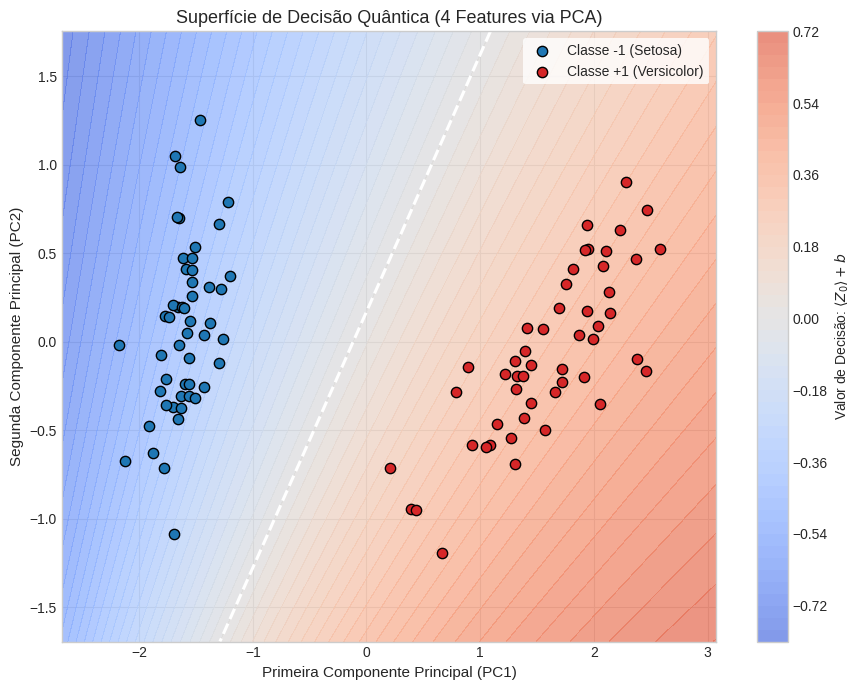

In [22]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from pennylane import numpy as np
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import pennylane as qp

# 1. Configuração do Dispositivo e Estética
dev = qp.device("default.qubit", wires=2)
plt.style.use("seaborn-v0_8-whitegrid")

# 2. Carregamento e Preparação dos Dados (forçando tipos float)
iris = load_iris()
X_raw = iris.data[:100].astype(float)
Y_raw = iris.target[:100]
Y = np.where(Y_raw == 0, -1.0, 1.0)  # Rótulos como float (-1.0 ou 1.0)

# Normalização L2 das features para AmplitudeEmbedding
normalization = np.sqrt(np.sum(X_raw**2, axis=-1, keepdims=True))
X_norm = X_raw / normalization

# Divisão de Treino e Teste
feats_train, feats_test, Y_train, Y_test = train_test_split(
    X_norm, Y, test_size=0.20, random_state=42, stratify=Y
)


# 3. Definição do Circuito e Classificador
def layer(layer_weights):
  for wire in range(2):
    qp.Rot(*layer_weights[wire], wires=wire)
  qp.CNOT(wires=[0, 1])


@qp.qnode(dev)
def circuit(weights, x):
  qp.AmplitudeEmbedding(x, wires=range(2), normalize=True)
  for layer_weights in weights:
    layer(layer_weights)
  return qp.expval(qp.PauliZ(0))


def variational_classifier(weights, bias, x):
  return circuit(weights, x) + bias


def square_loss(labels, predictions):
  return np.mean((labels - qp.math.stack(predictions)) ** 2)


# 4. Inicialização do Modelo e Otimizador
np.random.seed(0)
num_layers = 6
weights = np.random.randn(num_layers, 2, 3, requires_grad=True) * 0.01
bias = np.array(0.0, requires_grad=True)
opt = qp.optimize.NesterovMomentumOptimizer(0.01)
batch_size = 5

patience = 8
patience_counter = 0
best_cost_val = float("inf")
best_weights = weights.copy()
best_bias = bias

# Variáveis globais de lote para a função de custo (Closure)
X_batch_global = None
Y_batch_global = None


def cost(weights, bias):
  predictions = [
      variational_classifier(weights, bias, x) for x in X_batch_global
  ]
  return square_loss(Y_batch_global, predictions)


def cost_eval(X_eval, Y_eval):
  predictions = [variational_classifier(weights, bias, x) for x in X_eval]
  return square_loss(Y_eval, predictions)


# Loop de Treino com Early Stopping
for it in range(60):
  batch_index = np.random.randint(0, len(feats_train), (batch_size,))
  X_batch_global = feats_train[batch_index]
  Y_batch_global = Y_train[batch_index]

  # O step agora otimiza apenas os pesos e o viés sem conflito de tipos de inteiros
  weights, bias = opt.step(cost, weights, bias)
  cost_val = cost_eval(feats_test, Y_test)

  if cost_val < best_cost_val:
    best_cost_val = cost_val
    best_weights = weights.copy()
    best_bias = bias
    patience_counter = 0
  else:
    patience_counter += 1

  if patience_counter > patience:
    break

# 5. Configuração do PCA para Visualização em 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_raw)

x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 60), np.linspace(y_min, y_max, 60)
)

# Mapeia a malha 2D de volta para o espaço original e normaliza
grid_2d = np.c_[xx.ravel(), yy.ravel()]
grid_4d_approx = pca.inverse_transform(grid_2d)
norm_factor = np.sqrt(np.sum(grid_4d_approx**2, axis=-1, keepdims=True))
grid_norm = grid_4d_approx / norm_factor

# 6. Avaliação da malha usando os PESOS OTIMIZADOS
z = np.array(
    [variational_classifier(best_weights, best_bias, pt) for pt in grid_norm]
)
Z = z.reshape(xx.shape)

# 7. Plotagem Estilizada com a Fronteira Correta
plt.figure(figsize=(9, 7))

contour = plt.contourf(
    xx, yy, Z, levels=50, cmap=cm.coolwarm, alpha=0.75, vmin=-1.0, vmax=1.0
)
plt.colorbar(contour, label=r"Valor de Decisão: $\langle Z_0 \rangle + b$")

plt.contour(
    xx, yy, Z, levels=[0], colors="white", linewidths=2.2, linestyles="--"
)

plt.scatter(
    X_pca[Y == -1, 0],
    X_pca[Y == -1, 1],
    c="#1f77b4",
    edgecolors="k",
    linewidths=1.0,
    s=55,
    label="Classe -1 (Setosa)",
)

plt.scatter(
    X_pca[Y == 1, 0],
    X_pca[Y == 1, 1],
    c="#d62728",
    edgecolors="k",
    linewidths=1.0,
    s=55,
    label="Classe +1 (Versicolor)",
)

plt.xlabel("Primeira Componente Principal (PC1)", fontsize=11)
plt.ylabel("Segunda Componente Principal (PC2)", fontsize=11)
plt.title("Superfície de Decisão Quântica (4 Features via PCA)", fontsize=13)
plt.legend(frameon=True, facecolor="white", edgecolor="none")
plt.tight_layout()

plt.show()